Використай цей шаблон в роботі з датасетом.    
Ти можеш додавати комірки за потреби, але не змінюй структуру і послідовність питань.    
Обмежся функціями з наведених бібліотек.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
1. Переглянь список .json файлів, доступних за адресою https://github.com/prust/wikipedia-movie-data/tree/master.    
Відкрий будь-який файл, що містить у своїй назві рік і ознайомся з його структурою.    
Тепер сформуй список файлів, які ти будеш завантажувати.    
Для формування послідовності слід використати функцію numpy.arange.    
Довжина послідовності має становити не менше 5 датасетів(наприклад з 1960 по 2000  рік включно).    
Повну адресу сформуй через конкатенацію рядків.

In [29]:
base_url="http://raw.githubusercontent.com/prust/wikipedia-movie-data/heads/master/movies-"
years=np.arange(1960,2010,10)
file_urls=[]
for year in years:
    full_link=base_url+str(year)+"s.json"
    file_urls.append(full_link)
print("Список посилань для завантаження:")
for url in file_urls:
    print(url)

Список посилань для завантаження:
http://raw.githubusercontent.com/prust/wikipedia-movie-data/heads/master/movies-1960s.json
http://raw.githubusercontent.com/prust/wikipedia-movie-data/heads/master/movies-1970s.json
http://raw.githubusercontent.com/prust/wikipedia-movie-data/heads/master/movies-1980s.json
http://raw.githubusercontent.com/prust/wikipedia-movie-data/heads/master/movies-1990s.json
http://raw.githubusercontent.com/prust/wikipedia-movie-data/heads/master/movies-2000s.json


2. Тепер послідовність дій наступна.   
Слід пройти по всім обраним тобою файлам, прочитати кожен, як json об'єкт.        
Позбутись зайвих стовпців: ['href', 'extract', 'thumbnail', 'thumbnail_width', 'thumbnail_height'].     
Залишити лише повні рядки(рядки без пропущених значень).     
Об'єднати інформацію з усіх файлів в єдиний датасет.

In [40]:
all_dataframes=[]
columns_to_remove=['href', 'extract', 'thumbnail', 'thumbnail_width', 'thumbnail_height']
for url in file_urls:
    try:
        df=pd.read_json(url)
        df=df.drop(columns=columns_to_remove, errors='ignore')
        df=df.dropna()
        all_dataframes.append(df)
        print(f"Файл {url.split('/')[-1]} успішно оброблено")
    except Exception as e:
        print(f"Помилка при завантаженні{url}:{e}")
if len(all_dataframes)>0:
    final_dataset=pd.concat(all_dataframes,ignore_index=True)
    print("\nОбробка завершена")
    print(final_dataset.head())

Файл movies-1960s.json успішно оброблено
Файл movies-1970s.json успішно оброблено
Файл movies-1980s.json успішно оброблено
Файл movies-1990s.json успішно оброблено
Файл movies-2000s.json успішно оброблено

Обробка завершена
                                title  year  \
0                       The 3rd Voice  1960   
1                      12 to the Moon  1960   
2                     13 Fighting Men  1960   
3                           13 Ghosts  1960   
4  The Adventures of Huckleberry Finn  1960   

                                                cast  \
0        [Edmond O'Brien, Laraine Day, Julie London]   
1                            [Ken Clark, Tom Conway]   
2                  [Grant Williams, Carole Matthews]   
3                       [Charles Herbert, Jo Morrow]   
4  [Tony Randall, Patty McCormack, Eddie Hodges, ...   

                                    genres  
0  [Mystery, Crime, Drama, Noir, Thriller]  
1           [Science Fiction, Independent]  
2                    

3. Перевір розмір фінального датасету. Він має включати 4(чотири) стовпчика. Кількість рядків залежить від обраної кількості файлів. Збережи собі копію у вигляді csv або json файлу. Це убезпечить тебе від форс-мажорів.

In [38]:
print(f"Розмір датасету:{final_dataset.shape}")
print(f"Стовпчики:{final_dataset.columns.tolist()}")
final_dataset.to_csv("movies_backup.csv",index=False)
print("Копію збережено у файл movies_backup.csv")

Розмір датасету:(10750, 4)
Стовпчики:['title', 'year', 'cast', 'genres']
Копію збережено у файл movies_backup.csv


4. Для json файлу не варто використовувати метод describe. Файл містить вкладені структури.    
Перевір вміст перших рядочків і використай метод info.

In [47]:
print("Інформація про датасет:")
final_dataset.info()
print("\nПерші рядки таблиці:")
pd.set_option('display.expand_frame_repr',False)
pd.set_option('display.max_columns',None)
print(final_dataset.head())

Інформація про датасет:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10750 entries, 0 to 10749
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   10750 non-null  object
 1   year    10750 non-null  int64 
 2   cast    10750 non-null  object
 3   genres  10750 non-null  object
dtypes: int64(1), object(3)
memory usage: 336.1+ KB

Перші рядки таблиці:
  title                                year cast                                               genres                                  
0                       The 3rd Voice  1960        [Edmond O'Brien, Laraine Day, Julie London]  [Mystery, Crime, Drama, Noir, Thriller]
1                      12 to the Moon  1960                            [Ken Clark, Tom Conway]           [Science Fiction, Independent]
2                     13 Fighting Men  1960                  [Grant Williams, Carole Matthews]                             [War, Drama]
3                           13 Gho

5. Тепер слід попрацювати з жанрами.    
Віднайди топ 10 жанрів за кількістю фільмів.    
Побудуй стовпчикову та кругову діаграму, а також виведи на екран підсумкову таблицю.

Топ-10 жанрів за кількістю фільмів:
genres
Comedy             3777
Drama              3758
Action             1228
Thriller           1158
Horror             1044
Romance             948
Crime               873
Science Fiction     708
Adventure           556
Western             492
Name: count, dtype: int64


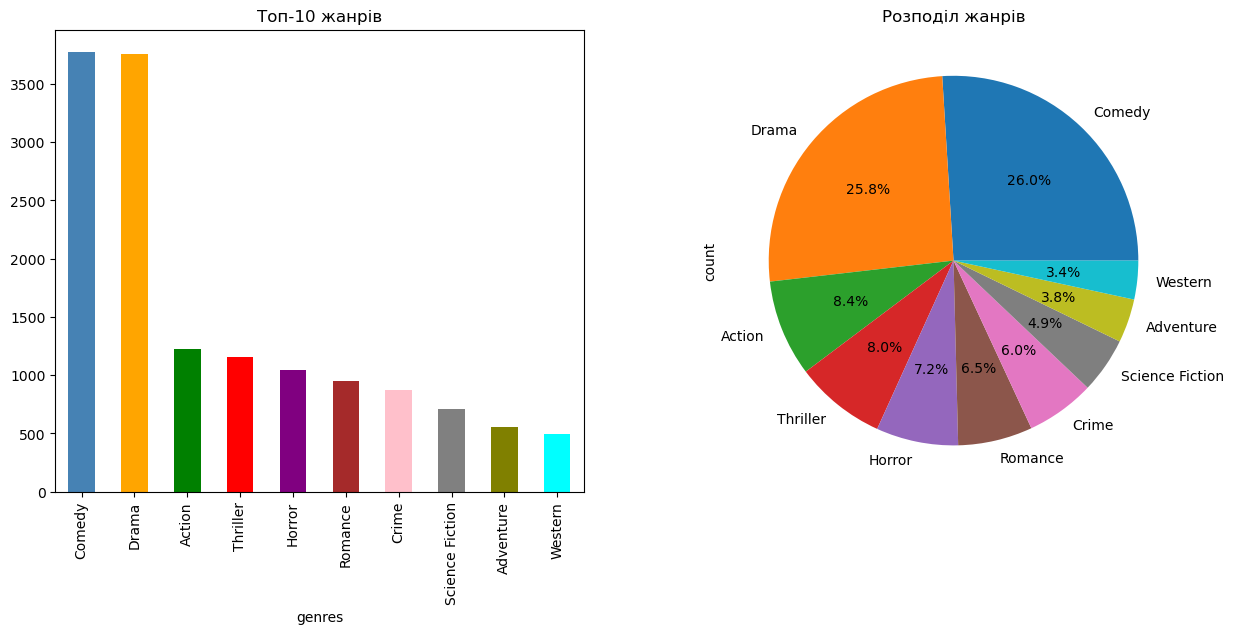

In [79]:
df_genres=final_dataset.explode('genres')
top_10_genres=df_genres['genres'].value_counts().head(10)
print("Топ-10 жанрів за кількістю фільмів:")
print(top_10_genres)
my_colors=['steelblue','orange','green','red','purple','brown','pink','gray','olive','cyan']
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(15,6))
top_10_genres.plot(kind='bar',ax=ax1,color=my_colors,title='Топ-10 жанрів')
top_10_genres.plot(kind='pie',ax=ax2, autopct='%1.1f%%', title='Розподіл жанрів')
plt.show()

6. Тепер вибери 3 найпопулярніших жанри і подивись, як змінювалась їх популярність впродовж обраного тобою часового періода.     
Для цього підрахуй кількість фільмів в кожному жанрі за кожен рік спостереження.    
Виведи результат у вигляді лінійного графіка.

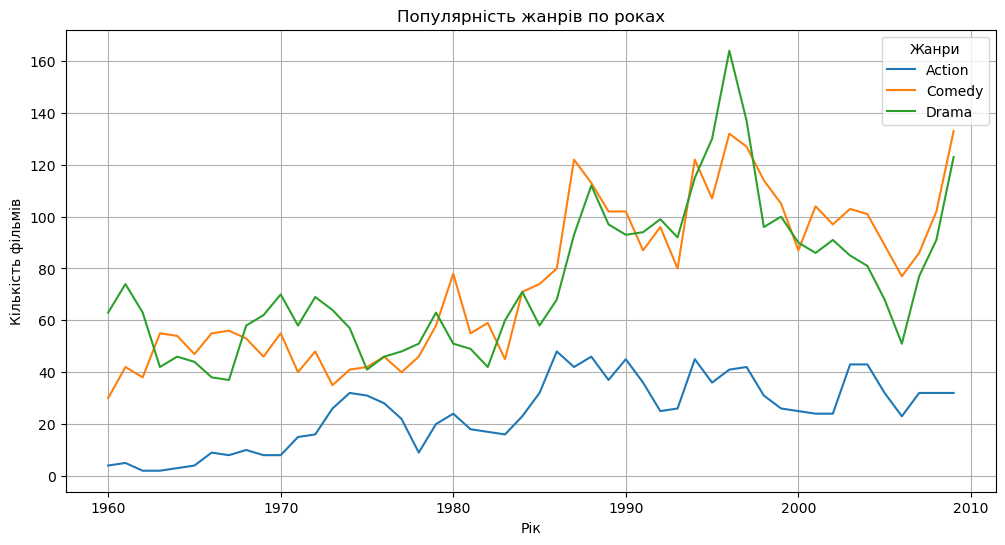

In [80]:
top_3_list=top_10_genres.head(3).index.tolist()
df_top3=df_genres[df_genres['genres'].isin(top_3_list)]
popularity_by_year=df_top3.groupby(['year','genres']).size().unstack().fillna(0)
popularity_by_year.plot(kind='line',figsize=(12,6))
plt.title(f'Популярність жанрів по роках')
plt.xlabel('Рік')
plt.ylabel('Кількість фільмів')
plt.grid(True)
plt.legend(title='Жанри')
plt.show()

7. Тепер слід попрацювати з акторами.     
Віднайди топ 10 акторів за кількістю фільмів.    
Побудуй стовпчикову або кругову діаграму, а також виведи на екран підсумукову таблицю.

Топ-10 акторів за кількістю фільмів:
cast
Gene Hackman          71
Robert Duvall         68
Robert De Niro        65
Burt Reynolds         63
Harvey Keitel         58
Christopher Walken    57
Donald Sutherland     57
Samuel L. Jackson     55
Michael Caine         54
Jack Nicholson        53
Name: count, dtype: int64


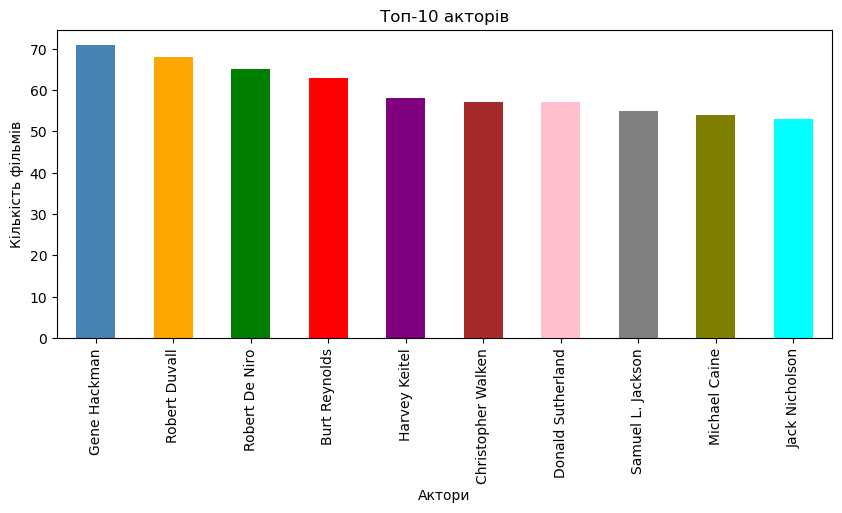

In [71]:
df_actors=final_dataset.explode('cast')
top_10_actors=df_actors['cast'].value_counts().head(10)
print("Топ-10 акторів за кількістю фільмів:")
print(top_10_actors)
my_colors=['steelblue','orange','green','red','purple','brown','pink','gray','olive','cyan']
top_10_actors.plot(kind='bar',figsize=(10,4),color=my_colors,title='Топ-10 акторів')
plt.xlabel('Актори')
plt.ylabel('Кількість фільмів')
plt.show()

8. Тепер вибери 3 найпопулярніших актори і подивись, як змінювалась їх популярність впродовж обраного тобою часового періода.
Для цього підрахуй кількість фільмів для кожного актора за кожен рік спостереження.    
Виведи результат у вигляді лінійного графіка.

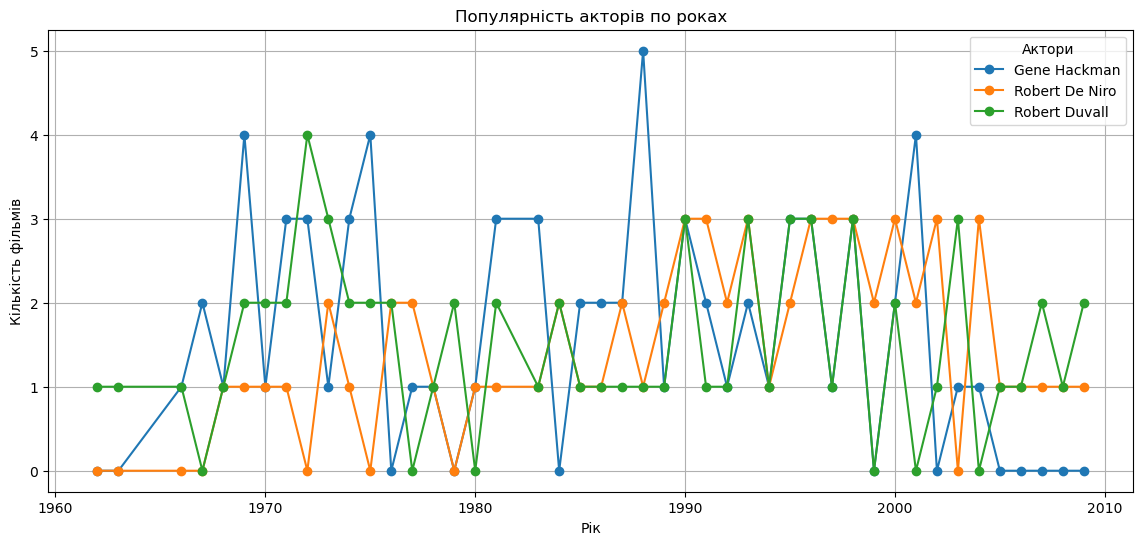

In [82]:
top_3_list=top_10_actors.head(3).index.tolist()
df_top3=df_actors[df_actors['cast'].isin(top_3_list)]
popularity_by_year=df_top3.groupby(['year','cast']).size().unstack().fillna(0)
popularity_by_year.plot(kind='line',figsize=(14,6),marker='o')
plt.title(f'Популярність акторів по роках')
plt.xlabel('Рік')
plt.ylabel('Кількість фільмів')
plt.grid(True)
plt.legend(title='Актори')
plt.show()

***Бонусне завдання***       
Зосередься лише на 10 найпопулярніших акторах.     
 Порахуй, як часто кожен актор з'являється в фільмі, що належить до категорії топ-3 найпопулярніших жанри, та як часто в фільмі, що не включає топовий жанр.  
 Оціни пропорції для кожного актора у вигляді стовпчикової діаграми та у вигляді таблиці, де вказано також відсоток фільмів в топ жанрах.

In [101]:
df_actors_and_genres=df_actors[df_actors['cast'].isin(top_10_actors.index)].copy()
df_actors_and_genres['is_top_genre']=df_actors_and_genres['genres'].apply(lambda x: any(genre in top_3_list for genre in x))
actors_stats=df_actors_and_genres.groupby(['cast','is_top_genre']).size().unstack(fill_value=0)
actors_stats=actors_stats.rename(columns={False:'Other genres',True:'Top 3 genres'})
actors_stats.columns.name=None
for col in ['Other genres','Top 3 genres']:
    if col not in actors_stats.columns:
        actors_stats[col]=0  
actors_stats['Total']=actors_stats['Top 3 genres']+actors_stats['Other genres']
actors_stats['% in Top genres']=(actors_stats['Top 3 genres']/actors_stats['Total']*100).round(2)
print("Статистика акторів у ТОП-3 жанрах:")
display(actors_stats.sort_values(by='% in Top genres',ascending=False))

Статистика акторів у ТОП-3 жанрах:


,Other genres,Top 3 genres,Total,% in Top genres
cast,,,,
Burt Reynolds,63,0,63,0.0
Christopher Walken,57,0,57,0.0
Donald Sutherland,57,0,57,0.0
Gene Hackman,71,0,71,0.0
Harvey Keitel,58,0,58,0.0
Jack Nicholson,53,0,53,0.0
Michael Caine,54,0,54,0.0
Robert De Niro,65,0,65,0.0
Robert Duvall,68,0,68,0.0
